In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import time
from joblib import Parallel, delayed

📥 Téléchargement des données (ACWV et S&P 500)...
✅ Données prêtes : 3574 jours de cotation.

🚀 Lancement de l'optimisation sur 32 combinaisons...
Critère de classement : Maximisation du Ratio de Sharpe



,Config_Name,MA_Short,MA_Long,Leverage,CAGR,Max Drawdown,Sharpe Ratio
10,MA 60/200 - Lev x4.0,60,200,4.0,0.082266,-0.548551,0.409869
26,MA 70/200 - Lev x4.0,70,200,4.0,0.082266,-0.548551,0.409869
25,MA 70/200 - Lev x3.0,70,200,3.0,0.080335,-0.434506,0.445100
9,MA 60/200 - Lev x3.0,60,200,3.0,0.080335,-0.434506,0.445100
27,MA 70/200 - Lev x5.0,70,200,5.0,0.077146,-0.643222,0.388730
11,MA 60/200 - Lev x5.0,60,200,5.0,0.077146,-0.643222,0.388730
8,MA 60/200 - Lev x2.0,60,200,2.0,0.071473,-0.298701,0.515558
24,MA 70/200 - Lev x2.0,70,200,2.0,0.071473,-0.298701,0.515558
4,MA 60/150 - Lev x2.0,60,150,2.0,0.051238,-0.325976,0.396732
20,MA 70/150 - Lev x2.0,70,150,2.0,0.051238,-0.325976,0.396732



🏆 GRAPHIQUE DE LA MEILLEURE STRATÉGIE : MA 60/200 - Lev x4.0


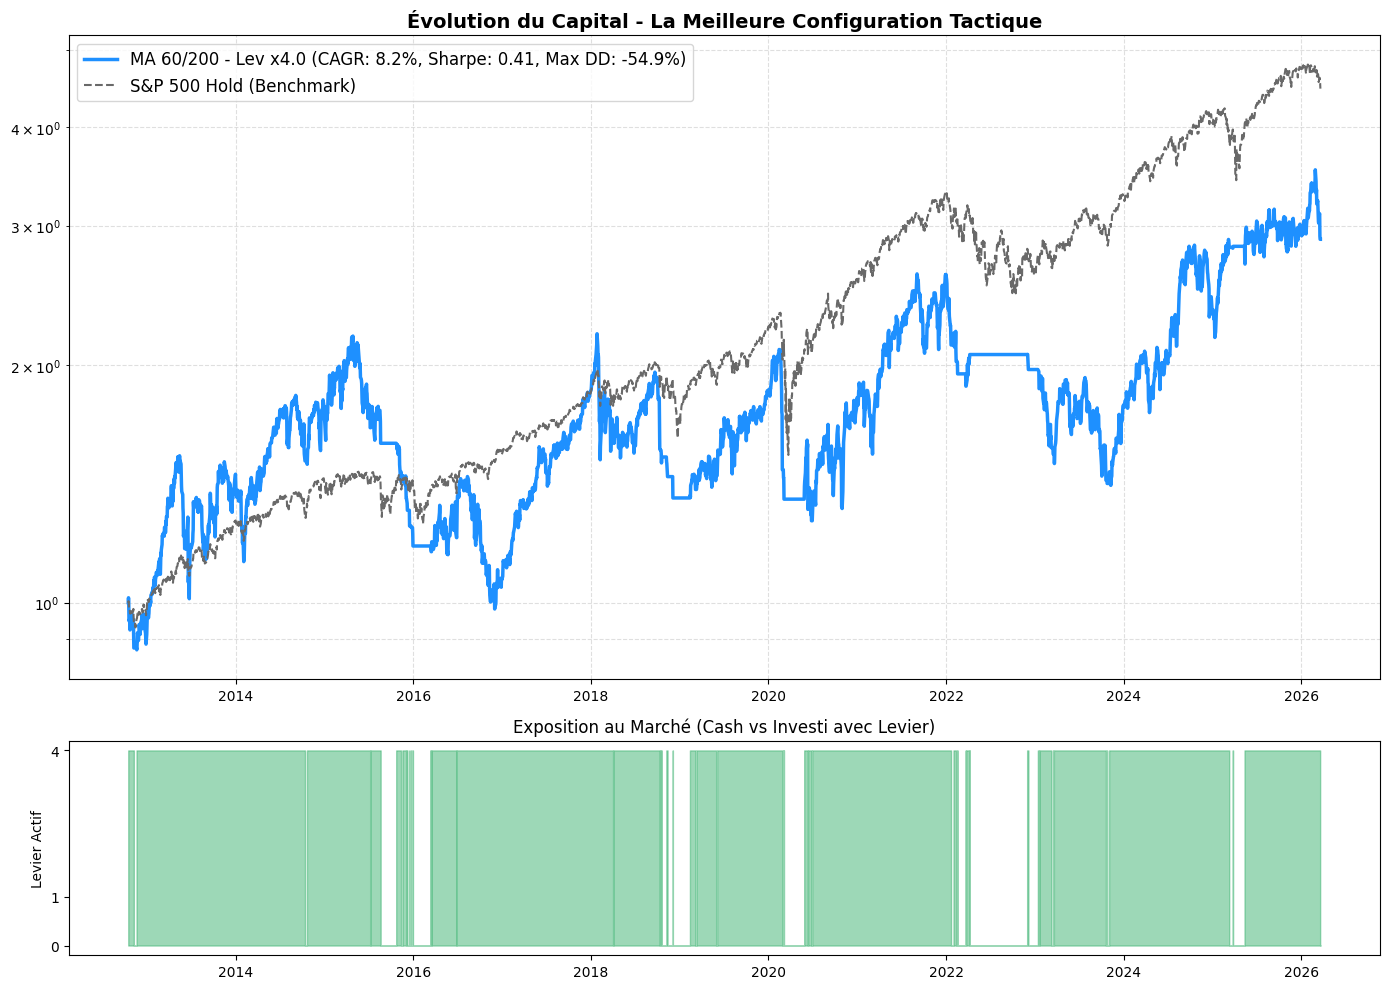

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import itertools
import matplotlib.pyplot as plt

# ==========================================
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ==========================================
def fetch_leveraged_data():
    print("📥 Téléchargement des données (ACWV et S&P 500)...")
    sp500 = yf.download('^GSPC', start='2012-01-01', end='2026-03-23', progress=False)['Close']
    etf = yf.download('ACWV', start='2012-01-01', end='2026-03-23', progress=False)['Close']
    
    # yfinance sometimes returns a Series, sometimes a DataFrame depending on the version.
    if isinstance(sp500, pd.DataFrame): sp500 = sp500.iloc[:, 0]
    if isinstance(etf, pd.DataFrame): etf = etf.iloc[:, 0]
        
    df = pd.DataFrame({'SP500': sp500, 'ETF': etf}).dropna().reset_index()
    df.columns = ['date', 'SP500', 'ETF']
    print(f"✅ Données prêtes : {len(df)} jours de cotation.\n")
    return df

# ==========================================
# 2. MOTEUR DE BACKTEST TACTIQUE 
# ==========================================
def run_tactical_leveraged_backtest(df, leverage, ma_short=50, ma_long=200, margin_rate=0.04):
    data = df.copy()
    
    # Calculate Moving Averages based on S&P 500
    data['MA_S'] = data['SP500'].rolling(ma_short).mean()
    data['MA_L'] = data['SP500'].rolling(ma_long).mean()
    
    # 🛠️ NOUVELLE LOGIQUE : Calculer les signaux basés sur les données d'hier 
    # pour trader aujourd'hui (Évite le Look-Ahead Bias)
    data['MA_S_Prev'] = data['MA_S'].shift(1)
    data['MA_L_Prev'] = data['MA_L'].shift(1)
    data['SP500_Prev'] = data['SP500'].shift(1)

    # LONG Conditions (evaluated on yesterday's close)
    buy_1 = (data['MA_S_Prev'] > data['MA_L_Prev']) & (data['SP500_Prev'] > data['MA_L_Prev'])
    buy_2 = (data['MA_S_Prev'] < data['MA_L_Prev']) & (data['SP500_Prev'] > data['MA_S_Prev'])
    data['Long_Signal'] = buy_1 | buy_2
    
    # SELL / CASH Conditions (evaluated on yesterday's close)
    sell_1 = (data['MA_S_Prev'] > data['MA_L_Prev']) & (data['SP500_Prev'] < data['MA_L_Prev'])
    sell_2 = (data['MA_S_Prev'] < data['MA_L_Prev']) & (data['SP500_Prev'] < data['MA_L_Prev'])
    data['Sell_Signal'] = sell_1 | sell_2
    
    # State Machine for Position
    data['Position'] = np.nan
    data.loc[data['Long_Signal'], 'Position'] = 1
    data.loc[data['Sell_Signal'], 'Position'] = 0
    data['Position'] = data['Position'].ffill().fillna(0)
    
    # Target weight applied for TODAY's return
    data['Target_Weight'] = data['Position'] * leverage
    
    # 🛠️ CORRECTION : We multiply TODAY's return by the Target Weight decided yesterday
    data['ETF_Return'] = data['ETF'].pct_change()
    data['Strat_Gross'] = data['Target_Weight'] * data['ETF_Return']
    
    # Calculate margin costs only on the borrowed portion (> 1.0)
    data['Borrowed_Weight'] = np.maximum(0, data['Target_Weight'] - 1.0)
    data['Daily_Margin_Cost'] = data['Borrowed_Weight'] * (margin_rate / 252)
    
    # Net Return
    data['Net_Return'] = data['Strat_Gross'] - data['Daily_Margin_Cost']
    
    # Drop rows where we don't have enough data to calculate MA_L
    data = data.dropna(subset=['Net_Return', 'MA_L'])
    
    # Compounding capital
    data['Capital'] = (1 + data['Net_Return']).cumprod()
    
    if data.empty: 
        return data, 0.0, 0.0, 0.0
        
    final_cap = data['Capital'].iloc[-1]
    n_years = len(data) / 252
    cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
    
    # Calculate Max Drawdown safely
    cum_max = data['Capital'].cummax()
    drawdown = (data['Capital'] - cum_max) / cum_max
    max_dd = drawdown.min()
    
    mean_ret = data['Net_Return'].mean()
    std_ret = data['Net_Return'].std()
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0.0
    
    return data, cagr, max_dd, sharpe

# ==========================================
# 3. LANCEMENT ET OPTIMISATION
# ==========================================
df_lev = fetch_leveraged_data()

param_grid = {
    'ma_short': [1050, 60, 70],          
    'ma_long': [100, 150, 200, 500],         
    'leverage': [2.0, 3.0, 4.0, 5.0]    
}

# Generate combinations ensuring ma_short < ma_long
combinations = [
    (s, l, lev) for s in param_grid['ma_short'] 
    for l in param_grid['ma_long'] 
    for lev in param_grid['leverage'] 
    if s < l
]

print(f"🚀 Lancement de l'optimisation sur {len(combinations)} combinaisons...")
print("Critère de classement : Maximisation du Ratio de Sharpe\n")

results_list = []
dfs_dict = {} 

for ma_s, ma_l, lev in combinations:
    res_df, cagr, max_dd, sharpe = run_tactical_leveraged_backtest(
        df_lev, leverage=lev, ma_short=ma_s, ma_long=ma_l, margin_rate=0.04
    )
    
    config_name = f"MA {ma_s}/{ma_l} - Lev x{lev}"
    dfs_dict[config_name] = res_df
    
    results_list.append({
        "Config_Name": config_name,
        "MA_Short": ma_s, 
        "MA_Long": ma_l, 
        "Leverage": lev,
        "CAGR": cagr, 
        "Max Drawdown": max_dd, 
        "Sharpe Ratio": sharpe
    })

# Sort by Sharpe Ratio as requested in your print statement (or change to 'CAGR')
best_strats = pd.DataFrame(results_list).sort_values(by='CAGR', ascending=False)
display(best_strats.head(10))

# ==========================================
# 4. GRAPHIQUE
# ==========================================
# Retrieve the best configuration based on the sorted dataframe
best_config = best_strats.iloc[0]
best_name = best_config['Config_Name']
best_df = dfs_dict[best_name]

print(f"\n🏆 GRAPHIQUE DE LA MEILLEURE STRATÉGIE : {best_name}")

# Prepare Benchmark (S&P 500) aligned with the strategy's start date
bench_df = df_lev.copy().dropna()
bench_df = bench_df.loc[bench_df['date'] >= best_df['date'].iloc[0]].copy()
bench_df['SP500_Return'] = bench_df['SP500'].pct_change()
bench_df['SP500_Capital'] = (1 + bench_df['SP500_Return'].fillna(0)).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Main plot: Capital Evolution
ax1.plot(best_df['date'], best_df['Capital'], color='dodgerblue', linewidth=2.5, 
         label=f"{best_name} (CAGR: {best_config['CAGR']*100:.1f}%, Sharpe: {best_config['Sharpe Ratio']:.2f}, Max DD: {best_config['Max Drawdown']*100:.1f}%)")
ax1.plot(bench_df['date'], bench_df['SP500_Capital'], color='dimgray', 
         linewidth=1.5, linestyle='--', label="S&P 500 Hold (Benchmark)")

ax1.set_yscale('log')
ax1.set_title("Évolution du Capital - La Meilleure Configuration Tactique", fontsize=14, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.4)
ax1.legend(loc='upper left', fontsize=12)

# Subplot: Leverage Exposure
ax2.fill_between(best_df['date'], 0, best_df['Target_Weight'], color='mediumseagreen', alpha=0.5, step="pre")
ax2.set_title("Exposition au Marché (Cash vs Investi avec Levier)", fontsize=12)
ax2.set_yticks([0, 1.0, float(best_config['Leverage'])])
ax2.set_ylabel("Levier Actif")

plt.tight_layout()
plt.show()